# Load embeddings

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir, evaluations_dir
from embedding_utils import perform_pca_on_embeddings
from annotation_utils import load_marcotte_subtypes
from training_configuration import PATHWAYS_3C

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

from common import evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)

# Only keep central values
embedding_df = embedding_df[
    (embedding_df.depth == 0) & (embedding_df.n_hidden == 8)
]


subtypes_marcotte = load_marcotte_subtypes(embedding_df.cell_line.unique())

pca_embeddings_dict = {}
for model in PATHWAYS_3C:
    # print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model], n_components=8)


for model in PATHWAYS_3C:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

Explained variance for cytof_init BT20: [0.38448512 0.17635863 0.13802847 0.10823589 0.06895943 0.04840469
 0.03870241 0.01726754]; Total: 0.9804
Explained variance for cytof_init EVSAT: [0.32435144 0.20979809 0.14961179 0.12344904 0.07050232 0.05318481
 0.03076021 0.01457938]; Total: 0.9762
Explained variance for cytof_init HCC1500: [0.31937464 0.21499647 0.13045293 0.10415223 0.08290784 0.06450275
 0.04706261 0.0250327 ]; Total: 0.9885
Explained variance for cytof_init HCC2185: [0.37291253 0.18518735 0.14547525 0.09609679 0.0707102  0.06165935
 0.03222957 0.01768843]; Total: 0.9820
Explained variance for cytof_init MCF7: [0.34451403 0.23816536 0.16068684 0.08137308 0.06910574 0.04429069
 0.0322148  0.01897487]; Total: 0.9893
Explained variance for cytof_init UACC3199: [0.30799095 0.19594613 0.16067374 0.11047218 0.07701363 0.06184999
 0.03545911 0.02219603]; Total: 0.9716
Explained variance for cytof_init UACC893: [0.42436172 0.15737142 0.12168166 0.10681547 0.06665148 0.05153761
 0.

In [2]:
embedding_df

,cell_line,L1,context,samples,dataset,job,n_hidden,depth,dropout_rate,l1reg_inflater_output,...,L22,L23,L24,L25,L26,L27,L28,L29,L30,model
14820,c184A1,-0.046923,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14821,c184B5,-0.263869,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14822,cAU565,-0.018232,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14823,cBT474,0.241893,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14824,cBT483,0.358532,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129915,cUACC3199,0.695101,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129916,cUACC812,0.536255,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129917,cUACC893,-0.014209,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129918,cZR751,0.475155,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg


## Compute PCA across multistarts

In [3]:
pca_embedding_df = pd.concat(
    [
        pca_embeddings_dict[model].assign(model=model)
        for model in PATHWAYS_3C
    ]
)

## Load parameters

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools as itt
from sklearn.decomposition import PCA
from common import evaluations_dir
from training_configuration import PATHWAYS_3C

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)
# Subset to central values of (n_hidden, depth) and to split "all"
par_dev_df = par_dev_df[(par_dev_df.depth == 0) & (par_dev_df.n_hidden == 8) & (par_dev_df.samples == "all")]

not_param_cols = [
    "cell_line", "model", "context", "features",
    "samples", "dataset",
    "n_hidden", "depth", "dropout_rate",
    "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss", "inflater_output_reg_epoch", "inflater_bound",
    "n_epoch", "multiheaded",
    "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

# Compute mean parameter deviations across multistarts
mean_par_dev_df = par_dev_df.groupby(["model", "context", "cell_line", "samples"])[param_cols].mean().reset_index()

In [10]:
mean_par_dev_df

,model,context,cell_line,samples,ERBB3_dp_Y1289_kcat,ERBB2_dp_Y1248_kcat,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_recycle_kcat,MEK_dp_S222_kcat,...,TOPK_p_Y74_EGFR__Y1173_p_kw,TOPK_p_Y74_ERBB2__Y1248_p_kw,TOPK_p_Y74_ERBB3__Y1289_p_kw,ERK_p_Y204_bact,ERK_p_Y204_MEK__S222_p_kw,ERK_p_Y204_TOPK__Y74_p_kw,ERK_p_Y204_iMEK_0_kw,ERK_p_Y204_ERK__Y204_p_kw,RPS6KA1_p_S380_bact,RPS6KA1_p_S380_ERK__Y204_p_kw
0,EGFR_MAPK__logobs,cytof_init,c184A1,all,0.0,-0.278892,0.259960,0.000000,0.0,0.040510,...,0.000000,0.000000,0.000000,0.205269,-0.016613,0.000000,-0.017336,0.535437,0.000000,-0.122898
1,EGFR_MAPK__logobs,cytof_init,c184B5,all,0.0,-0.007463,0.248571,0.000000,0.0,-0.065542,...,0.000000,0.000000,0.000000,-0.015489,-0.321926,0.000000,-0.089348,1.032477,0.000000,-0.095622
2,EGFR_MAPK__logobs,cytof_init,cAU565,all,0.0,0.125969,0.289584,0.000000,0.0,0.051832,...,0.000000,0.000000,0.000000,0.047036,-0.303985,0.000000,-0.003633,-0.051741,0.000000,0.111288
3,EGFR_MAPK__logobs,cytof_init,cBT20,all,0.0,-0.068394,0.141826,0.000000,0.0,0.043382,...,0.000000,0.000000,0.000000,0.324976,0.047855,0.000000,0.428842,-0.164424,0.000000,0.114855
4,EGFR_MAPK__logobs,cytof_init,cBT474,all,0.0,-0.257036,0.229046,0.000000,0.0,-0.132872,...,0.000000,0.000000,0.000000,0.107712,-0.006818,0.000000,-0.183446,-0.027190,0.000000,-0.176239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,cUACC3199,all,0.0,0.000000,-0.018445,0.139327,0.0,0.000000,...,0.282340,-0.312554,0.131584,0.658813,0.386549,0.391125,0.420268,-0.120105,-0.343099,0.135773
228,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,cUACC812,all,0.0,0.000000,0.032553,-0.159400,0.0,0.000000,...,0.272862,0.056762,0.066417,-0.146375,0.065345,-0.183603,0.007318,0.222537,0.382695,0.094935
229,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,cUACC893,all,0.0,0.000000,0.000245,0.017002,0.0,0.000000,...,-1.430343,0.087126,0.016610,-0.167503,-0.044973,-0.055140,-0.118202,0.129423,0.024977,-0.349261
230,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,cZR751,all,0.0,0.000000,0.071130,-0.202230,0.0,0.000000,...,-0.001738,-0.111657,0.148686,0.056063,0.174226,-0.058343,-0.071568,0.204206,0.432582,0.080940


In [8]:
len(param_cols)

44

In [14]:
# Filter the dataframe first
df_sub = mean_par_dev_df[
    (mean_par_dev_df.model == "EGFR_MAPK__logobs") &
    (mean_par_dev_df.context == "cytof_init") &
    (mean_par_dev_df.samples == "all")
]

# Compute std dev per parameter
std_nonzero = df_sub[param_cols].std()

# Keep only parameters with non-zero std
params_nonzero = std_nonzero[std_nonzero > 0].index.tolist()

## Naive parameter deviation-parameter deviation correlation; average linkage

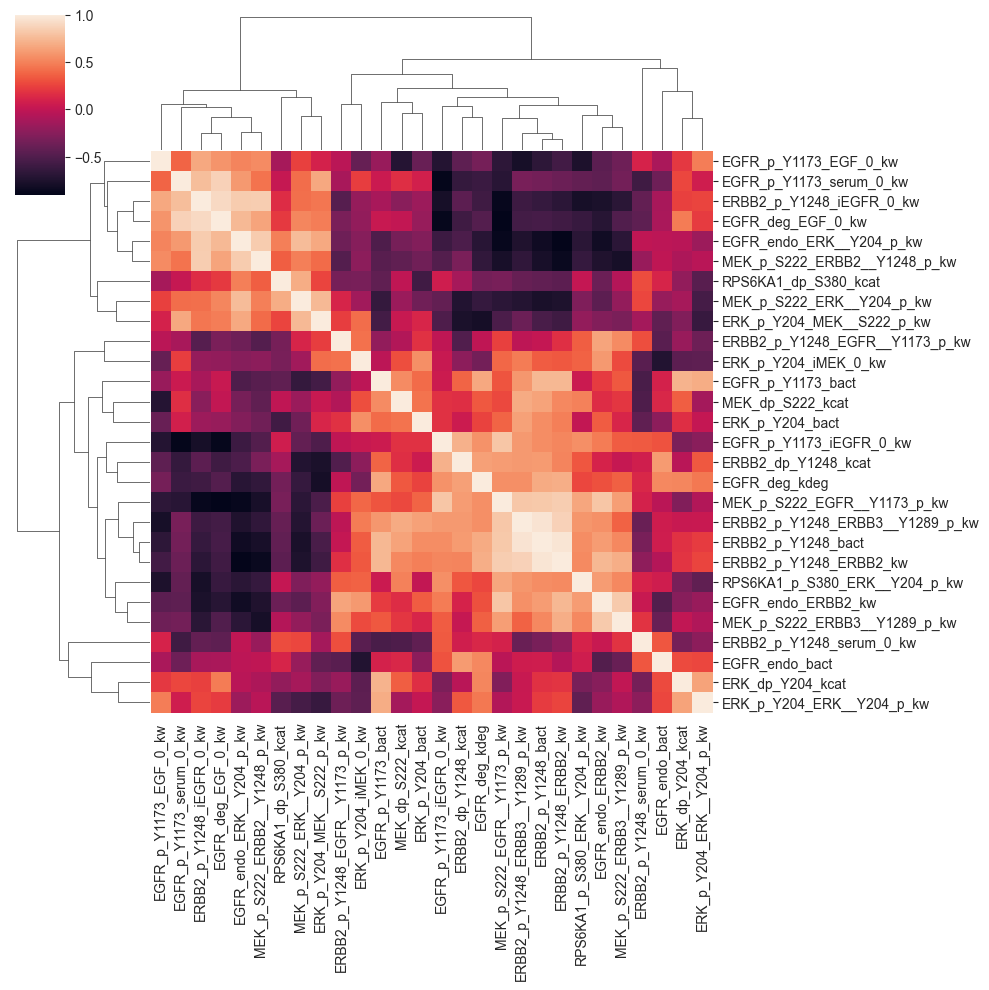

In [17]:
sns.clustermap(df_sub[params_nonzero].corr(),  method='average')

## Less naive, 1-|corr|

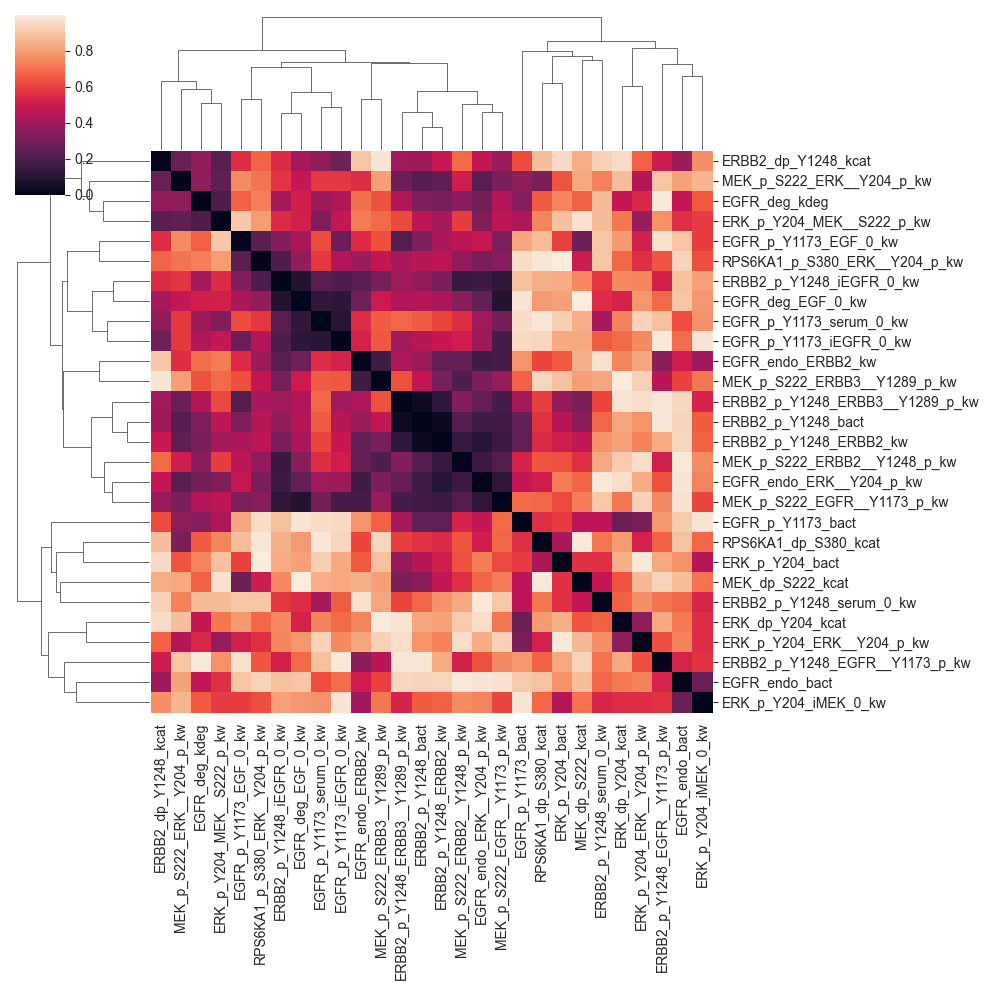

In [16]:
import numpy as np

# compute correlation matrix
C = df_sub[params_nonzero].corr()

# absolute-correlation distance
distance_matrix = 1 - np.abs(C)

sns.clustermap(
    distance_matrix,
    method="average"
)

## Use 1-|corr| to compute average linkage, then plot heatmap of |corr| with order according to the computed linkage -> most promising

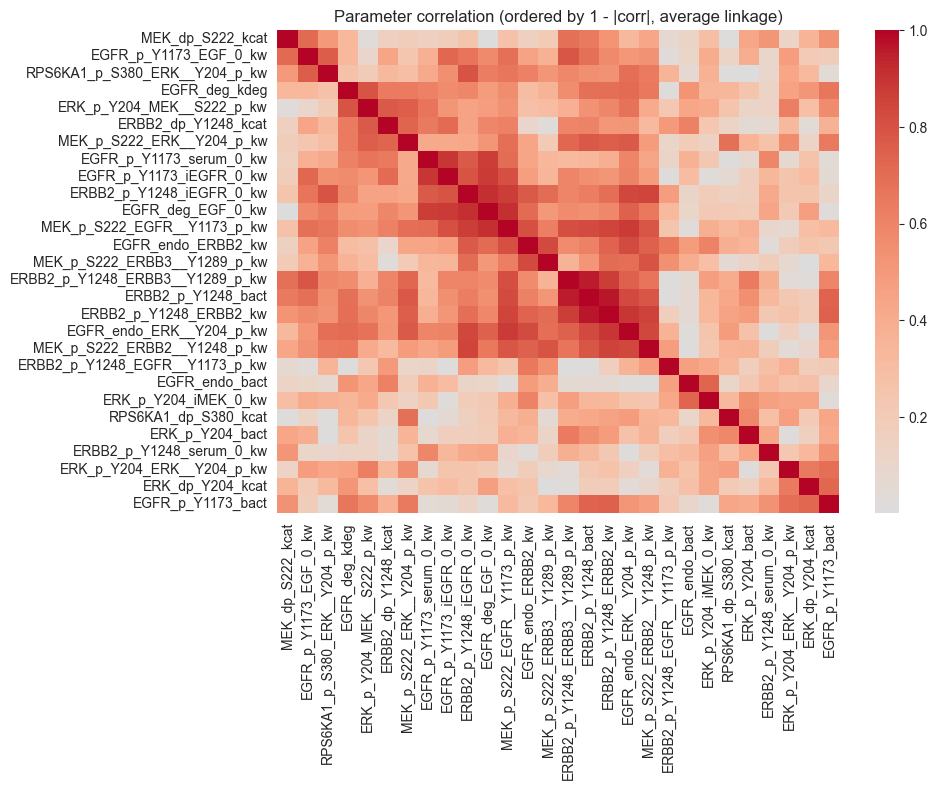

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# 1. Take the dataframe (parameters × samples)
df_params = df_sub[params_nonzero].T   # rows = parameters

# 2. Compute parameter–parameter correlation matrix
corr = df_params.T.corr()

# 3. Build distance matrix: 1 - |corr|
dist = 1 - np.abs(corr)

# Make sure diagonal is exactly 0
np.fill_diagonal(dist.values, 0)

# 4. Convert to condensed form and compute linkage (average linkage)
dist_condensed = squareform(dist.values)
Z = linkage(dist_condensed, method="average")

# 5. Get leaf order from the dendrogram
order = leaves_list(Z)
ordered_params = corr.index[order]

# 6. Reorder correlation matrix
corr_ordered = corr.loc[ordered_params, ordered_params]

# 7. Plot heatmap with this fixed order
plt.figure(figsize=(10, 8))
sns.heatmap(
    np.abs(corr_ordered),
    cmap="coolwarm",
    center=0,
    xticklabels=True,
    yticklabels=True
)
plt.title("Parameter correlation (ordered by 1 - |corr|, average linkage)")
plt.tight_layout()
plt.show()

# Run latent module pipeline

In [35]:
base_cytof_par_dev_df = par_dev_df[
    (par_dev_df.model == "EGFR_MAPK__logobs") & (par_dev_df.context == "cytof_init") & (par_dev_df.samples == "all")
]
lat_df = pca_embedding_df[
    (pca_embedding_df.model == "EGFR_MAPK__logobs") & (pca_embedding_df.context == "cytof_init") & (pca_embedding_df.samples == "all")
][[f"L{i}" for i in range(1, 9)]]

In [33]:
# Compute average parameters across multistarts
mean_base_cytof_par_dev_df = base_cytof_par_dev_df.groupby("cell_line")[params_nonzero].mean()

In [31]:
def transform_to_real_latents(Z_new):
    # For regression version:
    return Z_new @ A + b

Chosen K_opt=2, #singletons=0


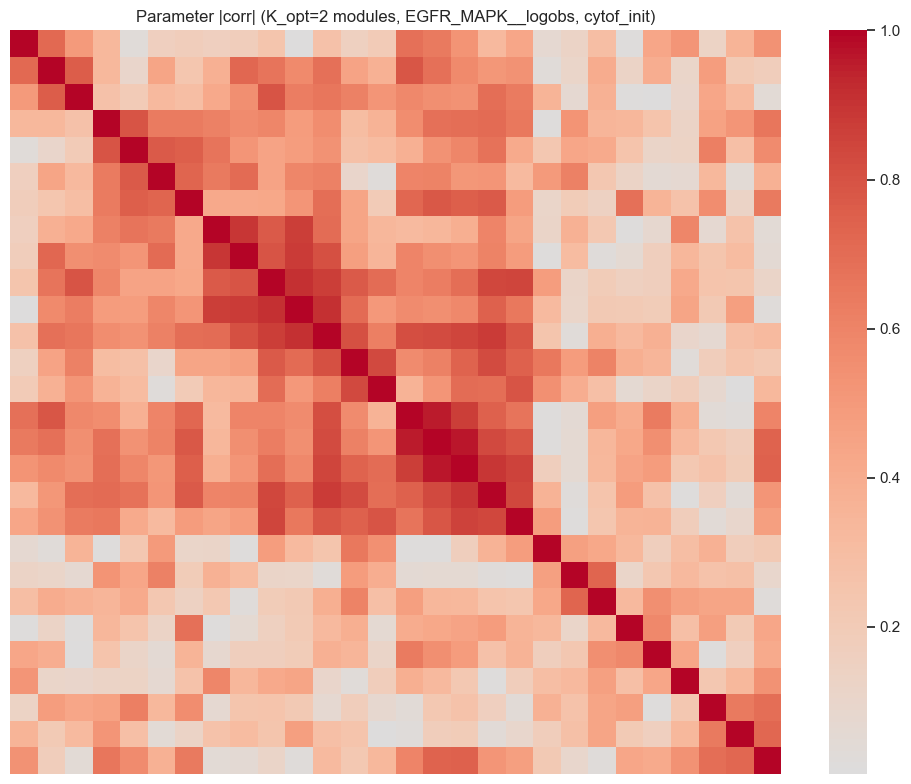

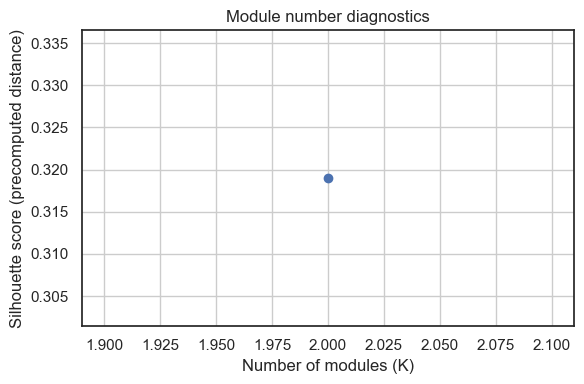

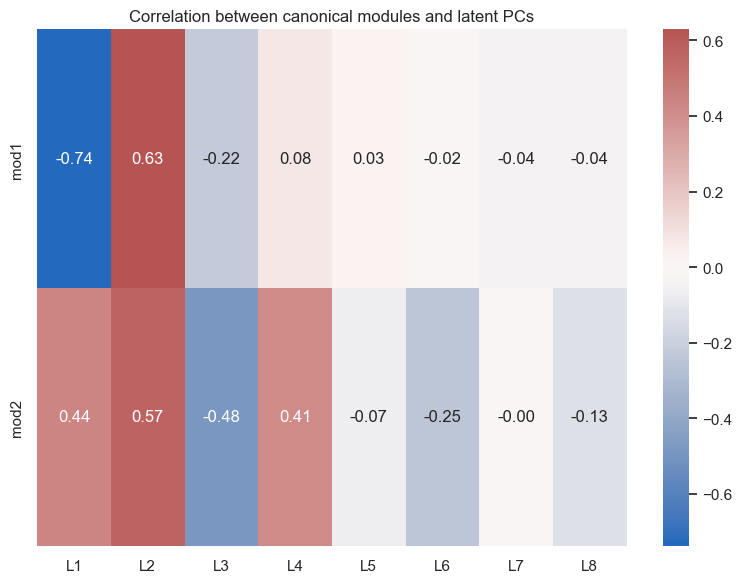

In [50]:
from embedding_utils import build_canonical_latents_from_params_and_pca

results = build_canonical_latents_from_params_and_pca(
    mean_par_dev_df=mean_par_dev_df,
    pca_embedding_df=pca_embedding_df.reset_index(),
    model="EGFR_MAPK__logobs",
    context="cytof_init",
    samples="all",
    max_modules=2,
    n_accepted_singletons=1,
    plot=True,
)

param_to_module   = results["param_to_module"]
K_opt             = results["K_opt"]
module_latents_df = results["module_latents_df"]
real_latents_df   = results["real_latents_df"]
A, b              = results["A"], results["b"]

In [51]:
param_to_module.sort_values()

ERBB2_dp_Y1248_kcat                1
ERK_p_Y204_MEK__S222_p_kw          1
MEK_p_S222_ERK__Y204_p_kw          1
MEK_p_S222_ERBB3__Y1289_p_kw       1
MEK_p_S222_ERBB2__Y1248_p_kw       1
MEK_p_S222_EGFR__Y1173_p_kw        1
EGFR_deg_EGF_0_kw                  1
EGFR_endo_ERBB2_kw                 1
EGFR_endo_ERK__Y204_p_kw           1
EGFR_p_Y1173_iEGFR_0_kw            1
EGFR_p_Y1173_EGF_0_kw              1
EGFR_p_Y1173_serum_0_kw            1
ERBB2_p_Y1248_iEGFR_0_kw           1
ERBB2_p_Y1248_ERBB3__Y1289_p_kw    1
ERBB2_p_Y1248_ERBB2_kw             1
ERBB2_p_Y1248_bact                 1
MEK_dp_S222_kcat                   1
EGFR_deg_kdeg                      1
RPS6KA1_p_S380_ERK__Y204_p_kw      1
ERK_p_Y204_ERK__Y204_p_kw          2
ERBB2_p_Y1248_serum_0_kw           2
EGFR_endo_bact                     2
ERBB2_p_Y1248_EGFR__Y1173_p_kw     2
RPS6KA1_dp_S380_kcat               2
ERK_dp_Y204_kcat                   2
ERK_p_Y204_bact                    2
ERK_p_Y204_iMEK_0_kw               2
E

In [38]:
real_emb = transform_to_real_latents(lat_df).sort_index()
lb_annot = pca_embedding_df[
    (pca_embedding_df.model == "EGFR_MAPK__logobs") & (pca_embedding_df.context == "cytof_init") & (pca_embedding_df.samples == "all")
].sort_index()["luminalbasal"]
real_emb = pd.DataFrame(
    real_emb.values,
    index=real_emb.index,
    columns=[f"RL{i+1}" for i in real_emb.columns]
)
real_emb["luminalbasal"] = lb_annot

In [39]:
real_emb

,RL1,RL2,RL3,RL4,RL5,RL6,luminalbasal
cell_line,,,,,,,
c184A1,0.614373,0.003268,0.871909,-1.959294,2.455767,-0.693595,Normal
c184B5,1.519352,-2.733027,0.598789,-0.958302,2.397600,0.240820,Normal
cAU565,-1.274333,-3.997318,0.203829,0.215378,0.785828,-0.371458,Luminal
cBT20,-1.110622,-3.496555,2.347521,-2.889203,0.093022,-0.614715,Basal
cBT474,2.121899,-0.378940,0.757523,-1.161134,-0.220079,1.838606,Luminal
cBT483,0.952043,3.784338,1.619270,-0.270443,-0.961373,-0.646885,Luminal
cBT549,1.631022,7.133767,0.303846,1.814786,-2.825287,0.977135,Basal
cCAL148,1.397117,5.186385,-3.343631,1.811865,-0.177417,0.911485,Luminal
cCAL51,-0.829448,1.291367,2.210211,1.351178,-0.992034,0.378355,Basal


<Axes: xlabel='RL1', ylabel='RL2'>

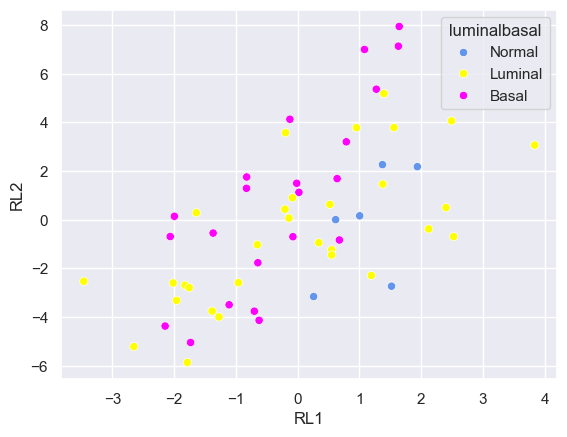

In [40]:
sns.scatterplot(
    data=real_emb,
    x="RL1",
    y="RL2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    }
)

<Axes: xlabel='RL2', ylabel='RL6'>

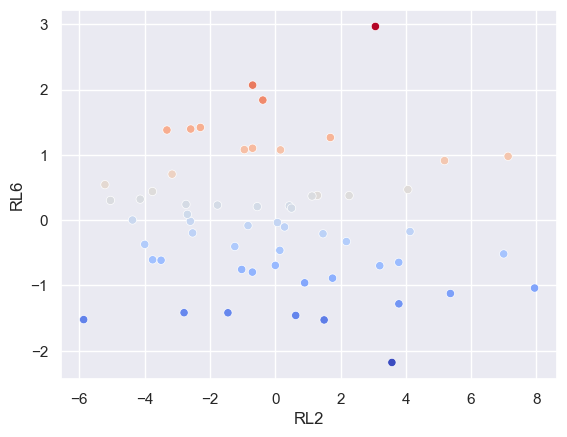

In [41]:
sns.scatterplot(
    data=real_emb,
    x="RL2",
    y="RL6",
    hue=mean_base_cytof_par_dev_df["ERBB2_p_Y1248_serum_0_kw"].sort_index(),
    palette="coolwarm",
    legend=False
)


In [42]:
def plot_module_param_grid(
    module_latents_df: pd.DataFrame,
    param_to_module: pd.Series,
    mean_par_dev_sub: pd.DataFrame,
    params_nonzero: list | None = None,
    max_params_per_module: int | None = None,
    palette: str = "coolwarm",
    height: float = 3.0,
    aspect: float = 1.0,
):
    """
    Systematic 2D plots in module space:

    - One row per module (module 1..N).
    - One column per parameter assigned to that module.
    - x-axis = module coordinate the parameter belongs to.
    - y-axis = most correlated other module coordinate.
    - hue = parameter value across cell lines.
    - Facet title includes: parameter name + "xcoord vs ycoord".
    """

    # --- Align cell_line index ---
    if "cell_line" in mean_par_dev_sub.columns:
        par_mean = mean_par_dev_sub.set_index("cell_line").sort_index()
    else:
        par_mean = mean_par_dev_sub.sort_index()

    mod_lat = module_latents_df.sort_index()
    common_cells = mod_lat.index.intersection(par_mean.index)
    if len(common_cells) == 0:
        raise ValueError("No overlapping cell_line entries.")

    mod_lat = mod_lat.loc[common_cells]
    par_mean = par_mean.loc[common_cells]

    # --- Non-zero variance params ---
    if params_nonzero is None:
        std_nonzero = par_mean[param_to_module.index].std()
        params_nonzero = std_nonzero[std_nonzero > 0].index.tolist()

    param_to_module = param_to_module.loc[param_to_module.index.intersection(params_nonzero)]

    # --- Module correlations & most correlated other module ---
    mod_corr = mod_lat.corr()
    most_corr_module = {}
    for mod_col in mod_lat.columns:
        r = mod_corr.loc[mod_col].drop(index=mod_col)
        most_corr_module[mod_col] = r.abs().idxmax()

    # --- Build long dataframe for FacetGrid ---
    rows = []

    for m_id in sorted(param_to_module.unique()):
        mod_col_x = f"mod{m_id}"
        if mod_col_x not in mod_lat.columns:
            continue
        mod_col_y = most_corr_module[mod_col_x]

        params_m = param_to_module.index[param_to_module == m_id].tolist()
        if max_params_per_module is not None:
            params_m = params_m[:max_params_per_module]

        for p in params_m:
            df_tmp = pd.DataFrame({
                "module": f"mod{m_id}",
                "param": p,
                "xcoord": mod_col_x,
                "ycoord": mod_col_y,
                "x": mod_lat[mod_col_x],
                "y": mod_lat[mod_col_y],
                "value": par_mean[p],
            }, index=common_cells)
            rows.append(df_tmp.reset_index(names="cell_line"))

    long_df = pd.concat(rows, ignore_index=True)

    # --- FacetGrid ---
    g = sns.FacetGrid(
        long_df,
        row="module",
        col="param",
        hue="value",
        palette=palette,
        sharex="row",
        sharey="row",
        margin_titles=True,
        height=height,
        aspect=aspect,
        despine=False,
    )
    g.map_dataframe(sns.scatterplot, x="x", y="y", legend=False)

    # --- Axis labels ---
    g.set_axis_labels("module coordinate", "most correlated module coordinate")

    # --- Add coordinate labels in the facet titles ---
    for ax in g.axes.flat:
        if ax is None:
            continue

        # Find param name for this facet
        if "param = " in ax.get_title():
            # FacetGrid row/col titles look like "module = mod2 | param = MY_PARAM"
            title = ax.get_title()
            try:
                param = title.split("param = ")[1]
                module = title.split("module = ")[1].split(" |")[0]
            except Exception:
                param = title
                module = ""

            # Retrieve x/y coordinate names
            sub_df = long_df[long_df["param"] == param]
            if not sub_df.empty:
                xcoord = sub_df["xcoord"].iloc[0]
                ycoord = sub_df["ycoord"].iloc[0]
                ax.set_title(f"{param}\n{xcoord} vs {ycoord}", fontsize=9)
        else:
            ax.set_title("")

    plt.tight_layout()
    plt.savefig("module_param_plot.pdf")
    plt.show()

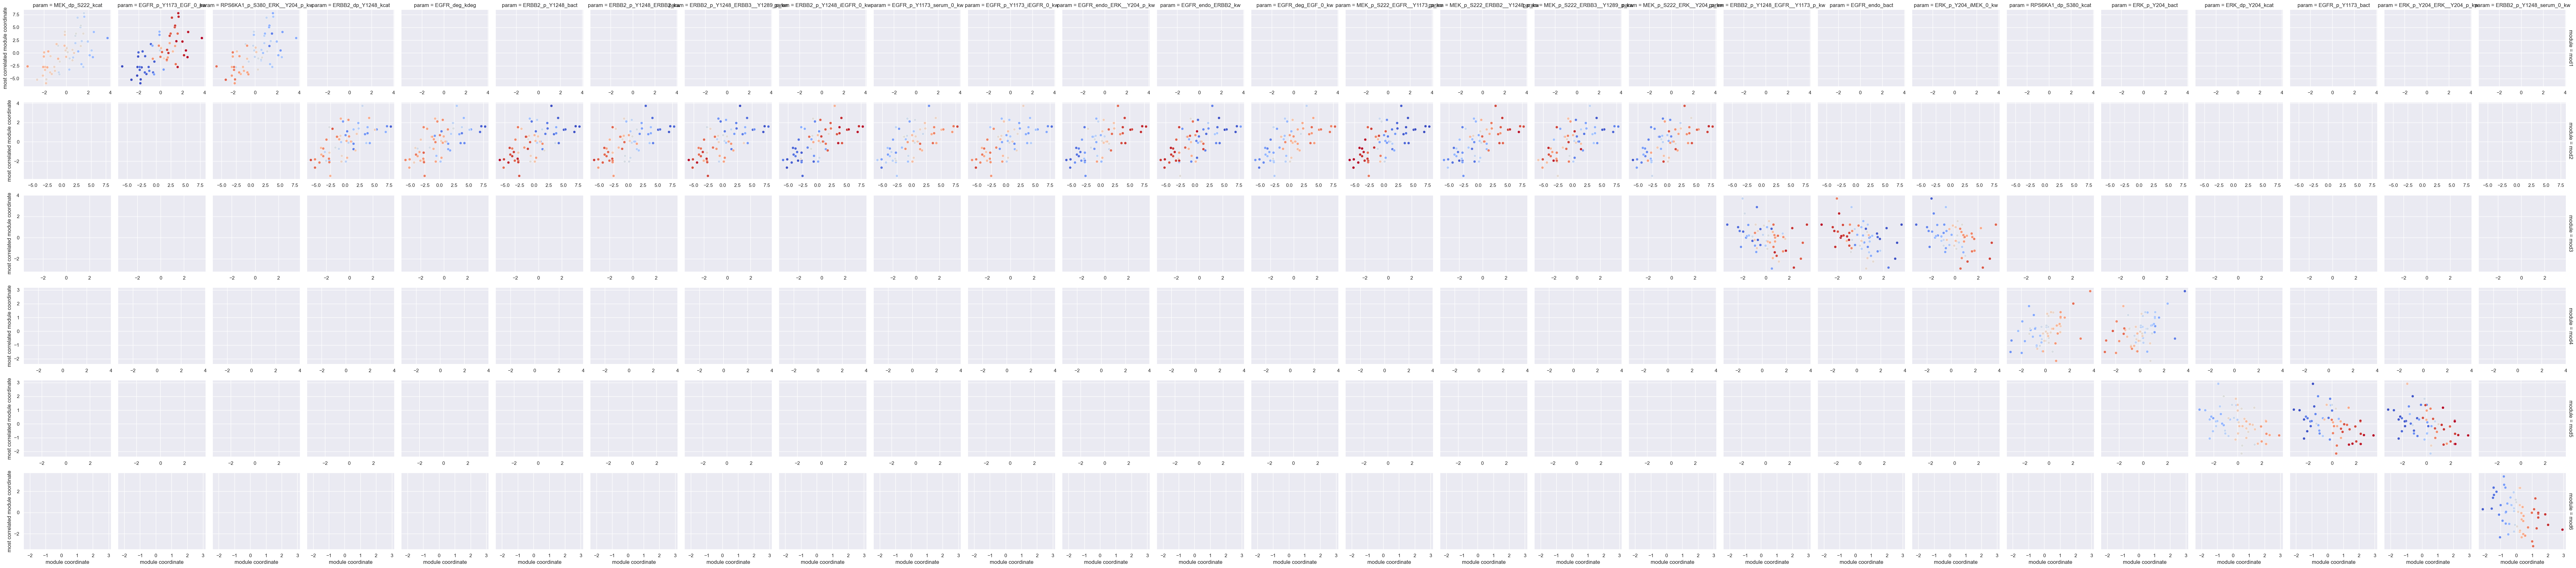

In [43]:
plot_module_param_grid(
    module_latents_df=module_latents_df,
    param_to_module=param_to_module,
    mean_par_dev_sub=mean_base_cytof_par_dev_df,
    params_nonzero=None,          # or your precomputed list
    max_params_per_module=15,      # e.g. cap columns per row
    palette="coolwarm",
)

Different plotting function, does not plot a whole grid with empty columns and rather plots one figure per latent module with all parameters in it

In [44]:
def plot_module_param_grid_per_module(
    module_latents_df: pd.DataFrame,
    param_to_module: pd.Series,
    mean_par_dev_sub: pd.DataFrame,
    params_nonzero: list | None = None,
    max_params_per_module: int | None = None,
    palette: str = "coolwarm",
    height: float = 3.0,
    aspect: float = 1.0,
):
    """
    For each module m:

      - Make ONE figure for that module.
      - Columns = parameters assigned to module m (optionally capped by max_params_per_module).
      - x-axis: module eigenscore for module m (e.g. 'mod2').
      - y-axis: eigenscore of the module most correlated with module m.
      - hue: parameter value across cell lines.
      - Facet title: "<param name>\\n<modX> vs <modY>".

    Parameters
    ----------
    module_latents_df : pd.DataFrame
        cell_line × modules, e.g. columns ['mod1','mod2',...].

    param_to_module : pd.Series
        index = parameter names,
        values = module id (1..K) each parameter belongs to.

    mean_par_dev_sub : pd.DataFrame
        Mean parameter deviations for the given (model, context, samples),
        one row per cell_line. Must contain all parameters in param_to_module.index.
        May have 'cell_line' as a column or already be indexed by cell_line.

    params_nonzero : list or None
        List of non-zero-variance parameters. If None, inferred from mean_par_dev_sub.

    max_params_per_module : int or None
        If not None, limit the number of parameters plotted per module.

    palette : str
        Colour palette for parameter values.

    height, aspect : float
        Size of each small subplot (FacetGrid height, aspect).
    """

    # --- Align cell_line index ---
    if "cell_line" in mean_par_dev_sub.columns:
        par_mean = mean_par_dev_sub.set_index("cell_line").sort_index()
    else:
        par_mean = mean_par_dev_sub.sort_index()

    mod_lat = module_latents_df.sort_index()
    common_cells = mod_lat.index.intersection(par_mean.index)
    if len(common_cells) == 0:
        raise ValueError("No overlapping cell_line entries between module_latents_df and mean_par_dev_sub.")

    mod_lat = mod_lat.loc[common_cells]
    par_mean = par_mean.loc[common_cells]

    # --- Non-zero variance params ---
    if params_nonzero is None:
        std_nonzero = par_mean[param_to_module.index].std()
        params_nonzero = std_nonzero[std_nonzero > 0].index.tolist()

    param_to_module = param_to_module.loc[param_to_module.index.intersection(params_nonzero)]

    if mod_lat.shape[1] < 2:
        raise ValueError("Need at least 2 modules in module_latents_df to define a second axis.")

    # --- Module correlations & most correlated other module ---
    mod_corr = mod_lat.corr()
    most_corr_module = {}
    for mod_col in mod_lat.columns:
        r = mod_corr.loc[mod_col].drop(index=mod_col)
        most_corr_module[mod_col] = r.abs().idxmax()

    # --- Loop over modules and make one plot per module ---
    unique_modules = sorted(param_to_module.unique())

    for m_id in unique_modules:
        mod_col_x = f"mod{m_id}"
        if mod_col_x not in mod_lat.columns:
            # If your naming is different, adjust mapping here
            continue

        mod_col_y = most_corr_module[mod_col_x]

        # Parameters in this module
        params_m = param_to_module.index[param_to_module == m_id].tolist()
        if not params_m:
            continue

        if max_params_per_module is not None:
            params_m = params_m[:max_params_per_module]

        # Build long df for this module only
        rows = []
        for p in params_m:
            df_tmp = pd.DataFrame(
                {
                    "param": p,
                    "xcoord": mod_col_x,
                    "ycoord": mod_col_y,
                    "x": mod_lat[mod_col_x],
                    "y": mod_lat[mod_col_y],
                    "value": par_mean[p],
                },
                index=common_cells,
            )
            rows.append(df_tmp.reset_index(names="cell_line"))

        long_df_m = pd.concat(rows, ignore_index=True)

        # FacetGrid: one row, len(params_m) columns
        g = sns.FacetGrid(
            long_df_m,
            col="param",
            hue="value",
            palette=palette,
            sharex=True,
            sharey=True,
            margin_titles=False,
            height=height,
            aspect=aspect,
            despine=False,
        )
        g.map_dataframe(sns.scatterplot, x="x", y="y", legend=False)

        # Axis labels
        g.set_axis_labels(mod_col_x, mod_col_y)

        # Set facet titles with coordinate labels
        for ax in g.axes.flat:
            if ax is None:
                continue
            title = ax.get_title()  # e.g. "param = ERBB2_p..."
            if "param = " in title:
                param_name = title.split("param = ", 1)[1]
                ax.set_title(f"{param_name}", fontsize=9)
            else:
                ax.set_title("")

        g.fig.suptitle(f"Module {m_id} ({mod_col_x})", y=1.05, fontsize=12)
        plt.tight_layout()
        plt.show()

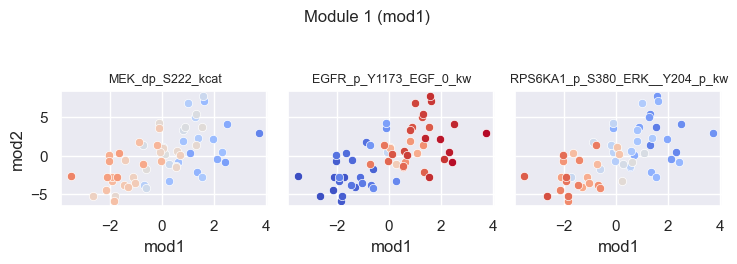

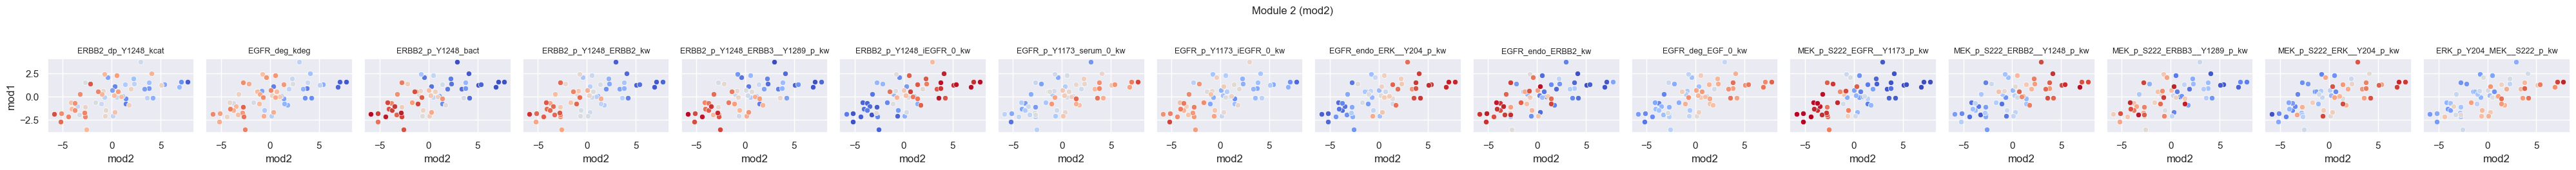

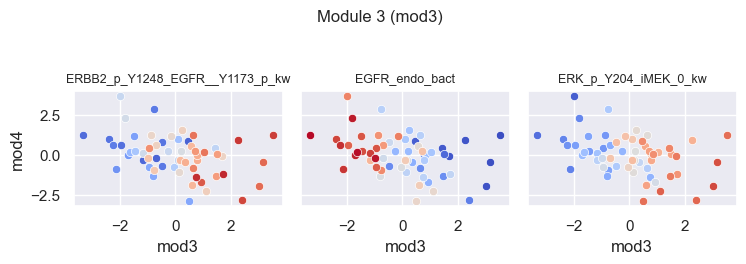

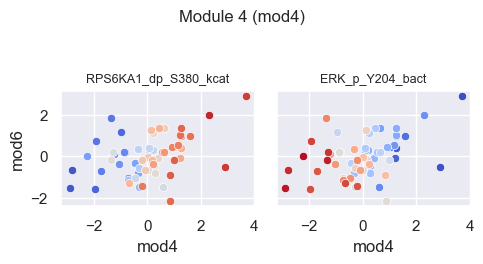

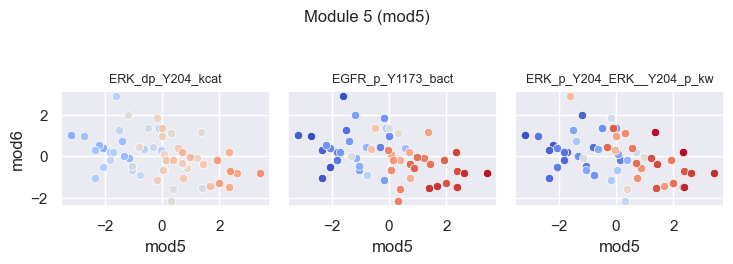

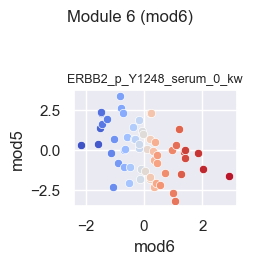

In [45]:
plot_module_param_grid_per_module(
    module_latents_df=module_latents_df,
    param_to_module=param_to_module,
    mean_par_dev_sub=mean_base_cytof_par_dev_df,
    max_params_per_module=None,
    palette="coolwarm",
    height=2.5,
    aspect=1.0,
)

In [66]:
mean_par_dev_df.columns

Index(['model', 'context', 'cell_line', 'samples', 'ERBB3_dp_Y1289_kcat',
       'ERBB2_dp_Y1248_kcat', 'EGFR_deg_kdeg', 'EGFR_dp_Y1173_kcat',
       'EGFR_recycle_kcat', 'MEK_dp_S222_kcat', 'TOPK_dp_Y74_kcat',
       'ERK_dp_Y204_kcat', 'RPS6KA1_dp_S380_kcat', 'ERBB3_p_Y1289_bact',
       'ERBB3_p_Y1289_serum_0_kw', 'ERBB2_p_Y1248_bact',
       'ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
       'ERBB2_p_Y1248_ERBB3__Y1289_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
       'ERBB2_p_Y1248_iEGFR_0_kw', 'EGFR_p_Y1173_bact',
       'EGFR_p_Y1173_EGF_0_kw', 'EGFR_p_Y1173_serum_0_kw',
       'EGFR_p_Y1173_iEGFR_0_kw', 'EGFR_endo_bact', 'EGFR_endo_ERK__Y204_p_kw',
       'EGFR_endo_EGFR_kw', 'EGFR_endo_ERBB2_kw', 'EGFR_deg_bact',
       'EGFR_deg_EGF_0_kw', 'MEK_p_S222_bact', 'MEK_p_S222_EGFR__Y1173_p_kw',
       'MEK_p_S222_ERBB2__Y1248_p_kw', 'MEK_p_S222_ERBB3__Y1289_p_kw',
       'MEK_p_S222_ERK__Y204_p_kw', 'MEK_p_S222_iMEK_0_kw', 'TOPK_p_Y74_bact',
       'TOPK_p_Y74_EGFR__Y1173_p

In [65]:
mean_base_cytof_par_dev_df.columns

Index(['ERBB2_dp_Y1248_kcat', 'EGFR_deg_kdeg', 'MEK_dp_S222_kcat',
       'ERK_dp_Y204_kcat', 'RPS6KA1_dp_S380_kcat', 'ERBB2_p_Y1248_bact',
       'ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
       'ERBB2_p_Y1248_ERBB3__Y1289_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
       'ERBB2_p_Y1248_iEGFR_0_kw', 'EGFR_p_Y1173_bact',
       'EGFR_p_Y1173_EGF_0_kw', 'EGFR_p_Y1173_serum_0_kw',
       'EGFR_p_Y1173_iEGFR_0_kw', 'EGFR_endo_bact', 'EGFR_endo_ERK__Y204_p_kw',
       'EGFR_endo_ERBB2_kw', 'EGFR_deg_EGF_0_kw',
       'MEK_p_S222_EGFR__Y1173_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw',
       'MEK_p_S222_ERBB3__Y1289_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
       'ERK_p_Y204_bact', 'ERK_p_Y204_MEK__S222_p_kw', 'ERK_p_Y204_iMEK_0_kw',
       'ERK_p_Y204_ERK__Y204_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw'],
      dtype='object')

In [69]:
mean_par_dev_df[
    (mean_par_dev_df.model == "EGFR_MAPK__logobs") & (mean_par_dev_df.context == "cytof_init")
]

,model,context,cell_line,samples,ERBB3_dp_Y1289_kcat,ERBB2_dp_Y1248_kcat,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_recycle_kcat,MEK_dp_S222_kcat,...,TOPK_p_Y74_EGFR__Y1173_p_kw,TOPK_p_Y74_ERBB2__Y1248_p_kw,TOPK_p_Y74_ERBB3__Y1289_p_kw,ERK_p_Y204_bact,ERK_p_Y204_MEK__S222_p_kw,ERK_p_Y204_TOPK__Y74_p_kw,ERK_p_Y204_iMEK_0_kw,ERK_p_Y204_ERK__Y204_p_kw,RPS6KA1_p_S380_bact,RPS6KA1_p_S380_ERK__Y204_p_kw
0,EGFR_MAPK__logobs,cytof_init,c184A1,all,0.0,-0.278892,0.259960,0.0,0.0,0.040510,...,0.0,0.0,0.0,0.205269,-0.016613,0.0,-0.017336,0.535437,0.0,-0.122898
1,EGFR_MAPK__logobs,cytof_init,c184B5,all,0.0,-0.007463,0.248571,0.0,0.0,-0.065542,...,0.0,0.0,0.0,-0.015489,-0.321926,0.0,-0.089348,1.032477,0.0,-0.095622
2,EGFR_MAPK__logobs,cytof_init,cAU565,all,0.0,0.125969,0.289584,0.0,0.0,0.051832,...,0.0,0.0,0.0,0.047036,-0.303985,0.0,-0.003633,-0.051741,0.0,0.111288
3,EGFR_MAPK__logobs,cytof_init,cBT20,all,0.0,-0.068394,0.141826,0.0,0.0,0.043382,...,0.0,0.0,0.0,0.324976,0.047855,0.0,0.428842,-0.164424,0.0,0.114855
4,EGFR_MAPK__logobs,cytof_init,cBT474,all,0.0,-0.257036,0.229046,0.0,0.0,-0.132872,...,0.0,0.0,0.0,0.107712,-0.006818,0.0,-0.183446,-0.027190,0.0,-0.176239
5,EGFR_MAPK__logobs,cytof_init,cBT483,all,0.0,-0.305986,-0.399545,0.0,0.0,-0.000735,...,0.0,0.0,0.0,0.067010,0.380962,0.0,0.286339,-0.303652,0.0,-0.161394
6,EGFR_MAPK__logobs,cytof_init,cBT549,all,0.0,-0.344972,-0.622912,0.0,0.0,-0.094722,...,0.0,0.0,0.0,-0.201513,0.527537,0.0,0.006405,-0.676543,0.0,-0.104590
7,EGFR_MAPK__logobs,cytof_init,cCAL148,all,0.0,0.054727,-0.089231,0.0,0.0,-0.044809,...,0.0,0.0,0.0,-0.150508,0.087966,0.0,-0.542172,0.173805,0.0,-0.173382
8,EGFR_MAPK__logobs,cytof_init,cCAL51,all,0.0,-0.404575,-0.194055,0.0,0.0,-0.014353,...,0.0,0.0,0.0,-0.084956,0.217036,0.0,0.155885,-0.704692,0.0,0.202211
9,EGFR_MAPK__logobs,cytof_init,cCAL851,all,0.0,-0.067804,-0.103266,0.0,0.0,0.091708,...,0.0,0.0,0.0,-0.074367,0.153814,0.0,0.210298,-0.579686,0.0,0.285104


Text(0.5, 1.0, 'Absolute correlation of top 10 parameters, base, cytof_init')

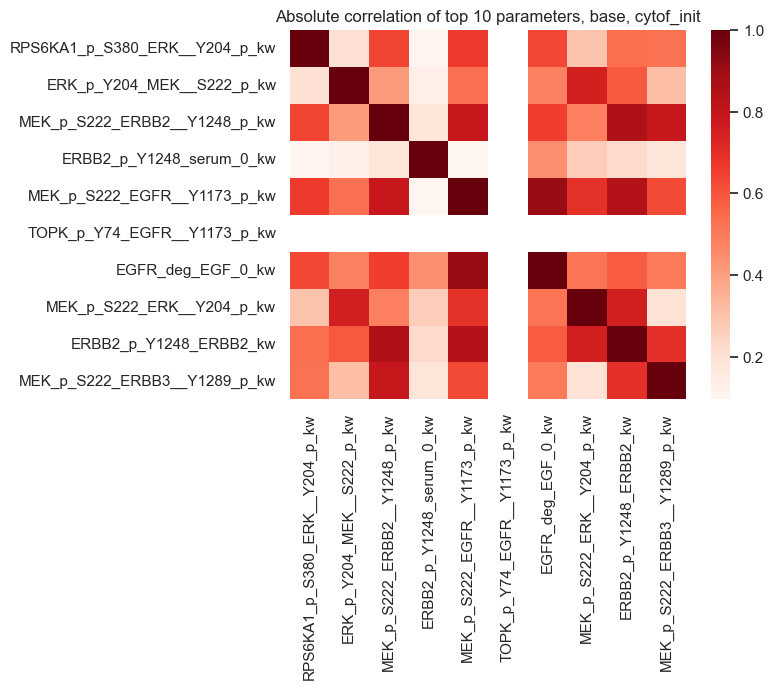

In [78]:
top_sensitive_cytof_base = [
    "RPS6KA1_p_S380_ERK__Y204_p_kw",
    "ERK_p_Y204_MEK__S222_p_kw",
    "MEK_p_S222_ERBB2__Y1248_p_kw",
    "ERBB2_p_Y1248_serum_0_kw",
    "MEK_p_S222_EGFR__Y1173_p_kw",
    "TOPK_p_Y74_EGFR__Y1173_p_kw",
    "EGFR_deg_EGF_0_kw",
    "MEK_p_S222_ERK__Y204_p_kw",
    "ERBB2_p_Y1248_ERBB2_kw",
    "MEK_p_S222_ERBB3__Y1289_p_kw"
]

sns.heatmap(
    np.abs(
        mean_par_dev_df[
            (mean_par_dev_df.model == "EGFR_MAPK__logobs") & (mean_par_dev_df.context == "cytof_init")
        ][top_sensitive_cytof_base].corr()
    ), cmap="Reds"
)
plt.title("Absolute correlation of top 10 parameters, base, cytof_init")